In [790]:
import warnings
warnings.filterwarnings('ignore')

- EDA - patterns, univariate, multivariate, NULL,Outlier, Dropping of columns
- Feature engineering - Scaling, Encoding
- Testing assumptions of LR
- Building the model
- Validation
- Evaluation metrics

In [791]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [792]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [793]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [794]:
df.nunique().sort_values()

guestroom             2
basement              2
mainroad              2
hotwaterheating       2
airconditioning       2
prefarea              2
furnishingstatus      3
bathrooms             4
parking               4
stories               4
bedrooms              6
price               219
area                284
dtype: int64

In [795]:
numerical = ["bathrooms","parking","stories","bedrooms","area"]
categorical = ["guestroom","basement","mainroad","hotwaterheating","airconditioning","prefarea","furnishingstatus"]

In [796]:
df[categorical] = df[categorical].replace({"yes":1,"no":0})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [797]:
ohe_fs = pd.get_dummies(df["furnishingstatus"], drop_first=True)
ohe_fs

,semi-furnished,unfurnished
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False
...,...,...
540,False,True
541,True,False
542,False,True
543,False,False


In [798]:
df = pd.concat([df,ohe_fs],axis=1)
df.drop(["furnishingstatus"],axis=1,inplace=True)

In [799]:
df[["semi-furnished","unfurnished"]]=df[["semi-furnished","unfurnished"]].astype(int)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [800]:
categorical = ["guestroom","basement","mainroad","hotwaterheating","airconditioning","prefarea","semi-furnished","unfurnished"]

In [801]:
df[categorical]=df[categorical].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   price            545 non-null    int64
 1   area             545 non-null    int64
 2   bedrooms         545 non-null    int64
 3   bathrooms        545 non-null    int64
 4   stories          545 non-null    int64
 5   mainroad         545 non-null    int64
 6   guestroom        545 non-null    int64
 7   basement         545 non-null    int64
 8   hotwaterheating  545 non-null    int64
 9   airconditioning  545 non-null    int64
 10  parking          545 non-null    int64
 11  prefarea         545 non-null    int64
 12  semi-furnished   545 non-null    int64
 13  unfurnished      545 non-null    int64
dtypes: int64(14)
memory usage: 59.7 KB


In [802]:
from sklearn.model_selection import train_test_split
df_train,df_val = train_test_split(df,test_size=0.2,random_state=42)
print("Train set: ",df_train.shape)
print("Test set: ", df_val.shape)

Train set:  (436, 14)
Test set:  (109, 14)


In [803]:
df_train.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
count,4.360000e+02,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000
mean,4.706527e+06,5154.144495,2.958716,1.266055,1.782110,0.857798,0.178899,0.357798,0.050459,0.307339,0.685780,0.233945,0.431193,0.314220
std,1.757976e+06,2204.313664,0.747804,0.477391,0.858093,0.349658,0.383708,0.479903,0.219141,0.461921,0.854941,0.423824,0.495812,0.464738
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.498250e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.291000e+06,4500.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.600000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1.225000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000


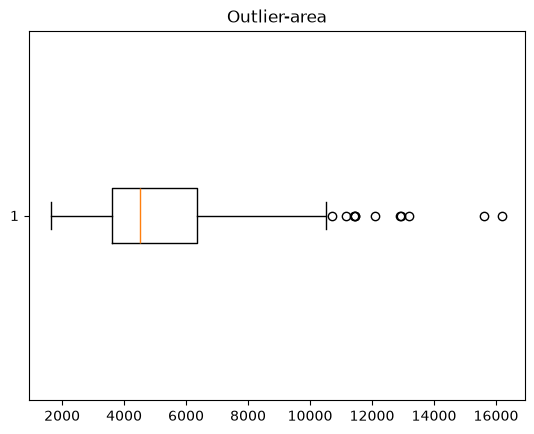

In [804]:
plt.boxplot(df_train["area"],vert=False)
plt.title("Outlier-area")
plt.show()

In [805]:
median_area = np.median(df["area"])
mad_area = np.median(np.abs(df["area"]-median_area))

modified_zscore = 0.6745*(df["area"] - median_area)/mad_area
modified_zscore.sort_values()

449   -1.431493
537   -1.407230
527   -1.341236
271   -1.307754
413   -1.285917
         ...   
403    4.048941
66     4.173165
10     4.173165
125    5.337770
7      5.628921
Name: area, Length: 545, dtype: float64

In [806]:
df_train['log_area'] = np.log(df_train["area"])
df_train['log_price'] = np.log(df_train["price"])
df_val['log_area'] = np.log(df_val["area"])
df_val['log_price'] = np.log(df_val["price"])

In [807]:
df_train.drop(["area","price"],axis=1,inplace=True)
df_val.drop(["area","price"],axis=1,inplace=True)

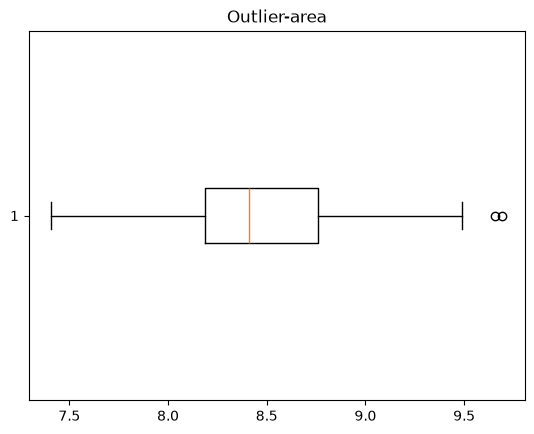

In [808]:
plt.boxplot(df_train["log_area"],vert=False)
plt.title("Outlier-area")
plt.show()

In [809]:
y_train = df_train.pop("log_price")
X_train = df_train

In [810]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 436 entries, 46 to 102
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bedrooms         436 non-null    int64  
 1   bathrooms        436 non-null    int64  
 2   stories          436 non-null    int64  
 3   mainroad         436 non-null    int64  
 4   guestroom        436 non-null    int64  
 5   basement         436 non-null    int64  
 6   hotwaterheating  436 non-null    int64  
 7   airconditioning  436 non-null    int64  
 8   parking          436 non-null    int64  
 9   prefarea         436 non-null    int64  
 10  semi-furnished   436 non-null    int64  
 11  unfurnished      436 non-null    int64  
 12  log_area         436 non-null    float64
dtypes: float64(1), int64(12)
memory usage: 47.7 KB


In [811]:
# Feature scaling
X_train.describe()

,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished,log_area
count,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000
mean,2.958716,1.266055,1.782110,0.857798,0.178899,0.357798,0.050459,0.307339,0.685780,0.233945,0.431193,0.314220,8.466549
std,0.747804,0.477391,0.858093,0.349658,0.383708,0.479903,0.219141,0.461921,0.854941,0.423824,0.495812,0.464738,0.398074
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.408531
25%,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.188689
50%,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.411833
75%,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,8.757784
max,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,9.692767


In [812]:
# Model Fitting

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
model = LinearRegression()

pipeline = Pipeline([("scaler",scaler),("model",model)])

pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['bedrooms','bathrooms','stories',...,'semi-furnished','unfurnished', 'log_area']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [813]:
y_val = df_val.pop("log_price")
X_val = df_val

In [814]:
print("Train R2 Score: ",pipeline.score(X_train,y_train))
print("Test R2 Score: ",pipeline.score(X_val,y_val))

Train R2 Score:  0.7153761618821262
Test R2 Score:  0.6782341334497208


Validate Assumptions of LR

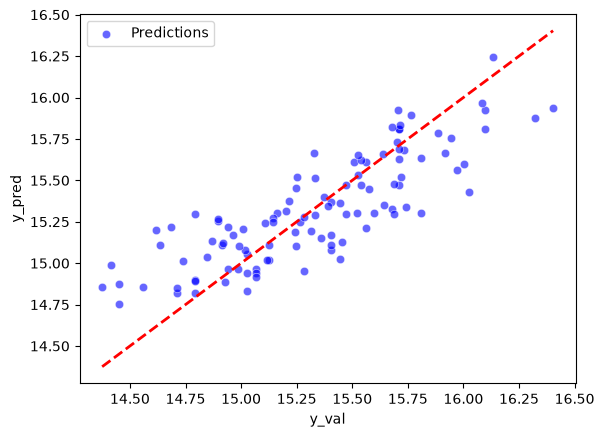

In [815]:
# Linearity - The relationship between the predictors (X) and the target (y) must be linear.

import seaborn as sns

y_pred  = pipeline.predict(X_val)
residual = y_val-y_pred

sns.scatterplot(x=y_val, y=y_pred, alpha=0.6, color='blue', label='Predictions')
plt.xlabel("y_val")
plt.ylabel("y_pred")
limits = [min(min(y_val), min(y_pred)), max(max(y_val), max(y_pred))]
plt.plot(limits, limits, color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y = x)')
plt.show()


Text(0.5, 1.0, 'Residuals vs. Fitted Values Plot (Linearity Check)')

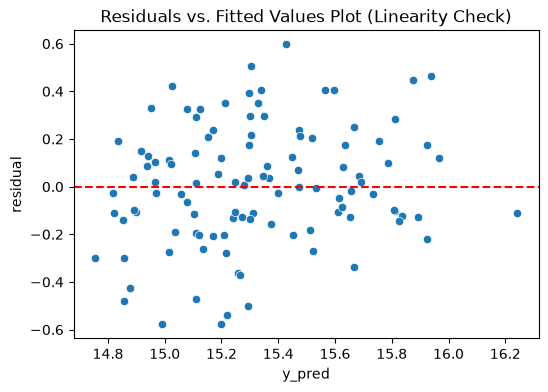

In [816]:
# Homosedacity : The variance of the residuals must be constant across all levels of predicted values. If variance changes (e.g., error spreads out in a funnel shape as values increase), it is called Heteroscedasticity.

plt.figure(figsize=(6,4))

sns.scatterplot(x=y_pred,y=residual)

plt.axhline(y=0, color='r', linestyle = '--')

plt.ylabel("residual")
plt.xlabel("y_pred")
plt.title('Residuals vs. Fitted Values Plot (Linearity Check)')

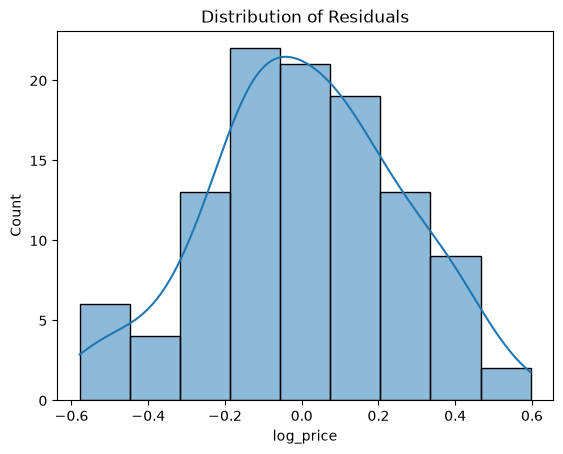

In [817]:
# Normality of Residuals

sns.histplot(residual,kde=True)
plt.title("Distribution of Residuals")
plt.show()

<Axes: >

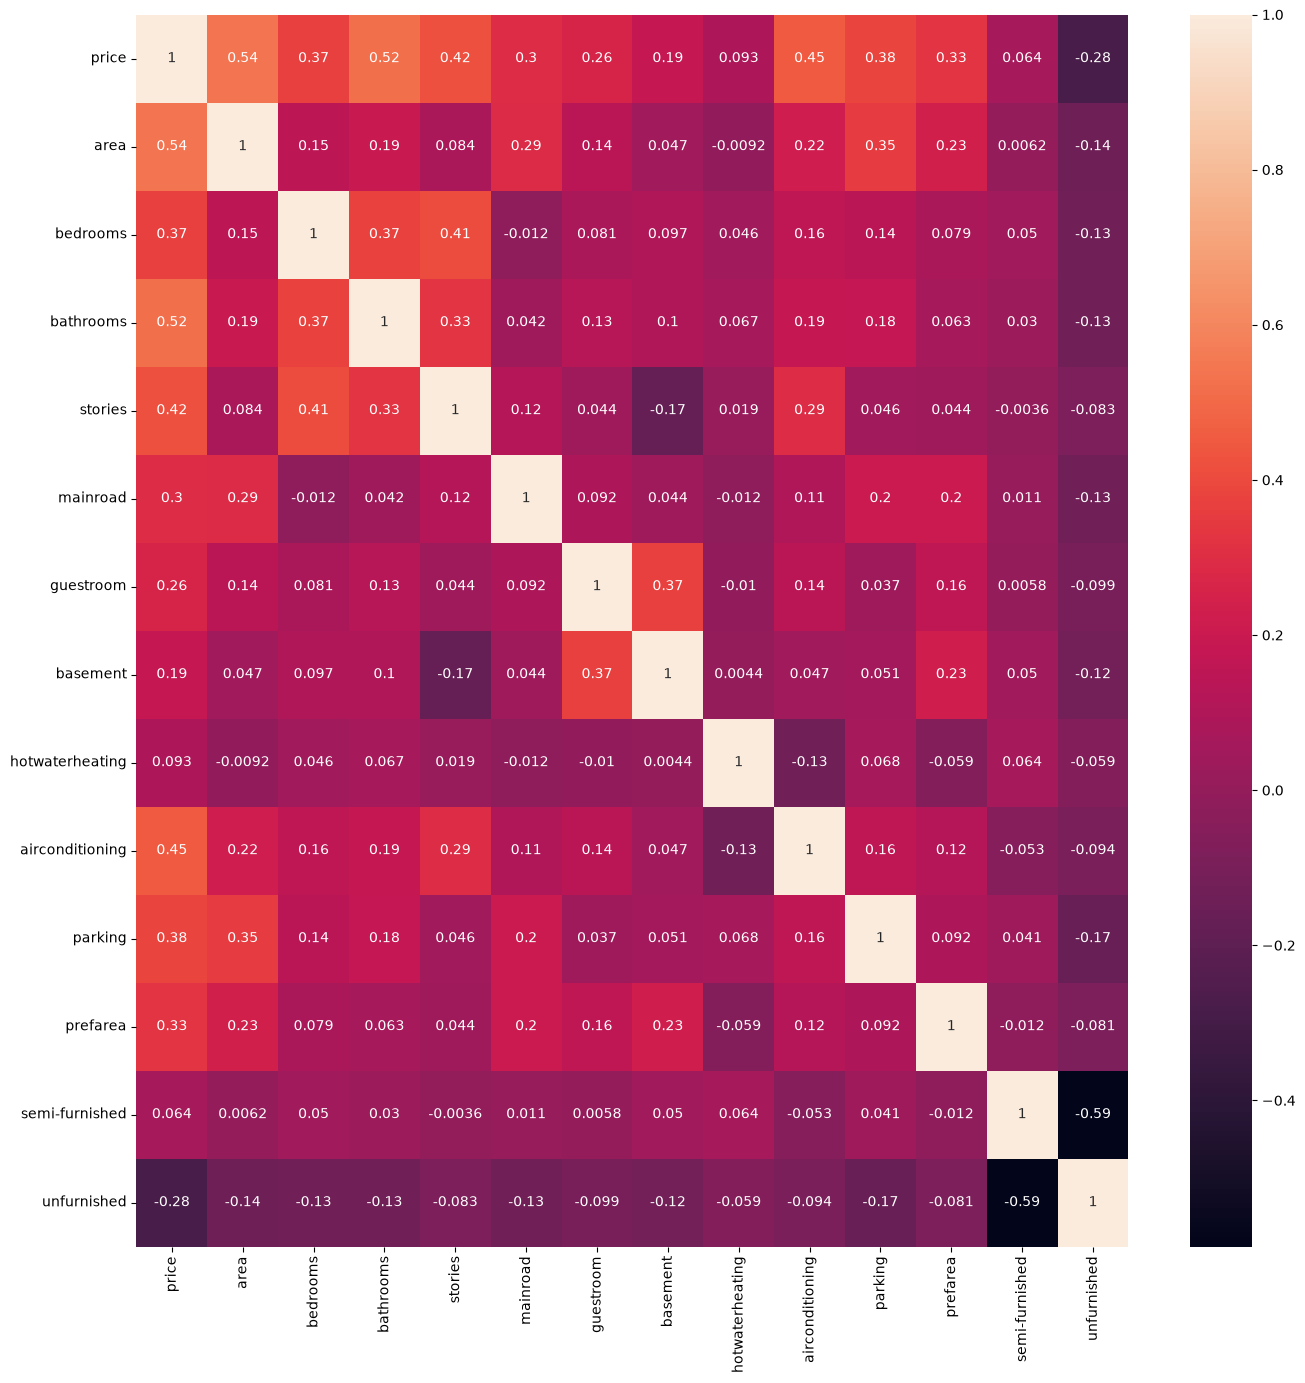

In [818]:
# No multicollinearity :  The independent features should not be highly correlated with each other

plt.figure(figsize=(16,16))
sns.heatmap(df.corr(),annot=True)  # 1. Look for pairwise correlations between features $> 0.8$.

In [819]:
# 2. VIF (Variance Inflation Factor): A VIF score tells you how much a feature is explained by other features.
# $VIF < 5$: Good (low collinearity)
# $VIF > 5$: Moderate collinearity (requires inspection)
# $VIF > 10$: High collinearity (violation; drop or combine features)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_const_train = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["Featrue"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_const_train.values,i+1) for i in range(len(X_train.columns))]

print(vif_data.sort_values(by="VIF",ascending=False))


            Featrue       VIF
11      unfurnished  1.696088
10   semi-furnished  1.587945
2           stories  1.515389
12         log_area  1.390321
5          basement  1.387680
0          bedrooms  1.380334
1         bathrooms  1.297626
4         guestroom  1.286239
7   airconditioning  1.281202
8           parking  1.220406
3          mainroad  1.217932
9          prefarea  1.133878
6   hotwaterheating  1.038493


In [820]:
numerical = ['bathrooms', 'parking', 'stories', 'bedrooms', 'log_area']

In [821]:
# LENIAR REGRESSION USING StatsModel

X_train[numerical] = scaler.fit_transform(X_train[numerical])
X_const_train = sm.add_constant(X_train)
lr = sm.OLS(y_train,X_const_train).fit()

In [822]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     81.59
Date:                Wed, 05 Aug 2026   Prob (F-statistic):          2.61e-106
Time:                        21:18:45   Log-Likelihood:                 109.70
No. Observations:                 436   AIC:                            -191.4
Df Residuals:                     422   BIC:                            -134.3
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              15.1367      0.034    4

In [823]:
X_val[numerical]=scaler.transform(X_val[numerical])
X_const_val = sm.add_constant(X_val)
y_pred = lr.predict(X_const_val)

In [824]:
from sklearn.metrics import r2_score

r2_score(y_val,y_pred)

0.6782341334497195